## Modelagem 
Avaliar e comparar utlizando dois modelos de classificação: 
1. Regressão logistica
2. SVM

In [18]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Regressão logistica

In [19]:
train_df = pd.read_csv('../data/processed/train.csv')
test_df = pd.read_csv('../data/processed/test.csv')

# separa features e target
input_train = train_df.drop('Outcome', axis=1)
outcome_train = train_df['Outcome']

input_test = test_df.drop('Outcome', axis=1)
outcome_test = test_df['Outcome']



In [20]:
lr_model = LogisticRegression(max_iter=1000,random_state=42)
lr_model.fit(input_train,outcome_train)
lr_pred = lr_model.predict(input_test)
print ("Modelo de regressão logistica executado com sucesso")

Modelo de regressão logistica executado com sucesso


## Avaliação da regressão logistica

In [21]:
print('=== Regressão Logística ===')
print(f'Accuracy:  {accuracy_score(outcome_test, lr_pred):.2f}')
print(f'Recall:    {recall_score(outcome_test, lr_pred):.2f}')
print(f'F1-score:  {f1_score(outcome_test, lr_pred):.2f}')

print('\n--- Relatório completo ---')
print(classification_report(outcome_test, lr_pred, 
      target_names=['Não diabético', 'Diabético']))

=== Regressão Logística ===
Accuracy:  0.71
Recall:    0.50
F1-score:  0.55

--- Relatório completo ---
               precision    recall  f1-score   support

Não diabético       0.75      0.82      0.78       100
    Diabético       0.60      0.50      0.55        54

     accuracy                           0.71       154
    macro avg       0.68      0.66      0.67       154
 weighted avg       0.70      0.71      0.70       154



## SVM

In [22]:
svm_model = SVC(kernel = 'rbf', random_state=42)
svm_model.fit(input_train, outcome_train)
svm_pred = svm_model.predict(input_test)

## Avalição Regressão Logistica

In [23]:
print('=== SVM ===')
print(f'Accuracy:  {accuracy_score(outcome_test, svm_pred):.2f}')
print(f'Recall:    {recall_score(outcome_test, svm_pred):.2f}')
print(f'F1-score:  {f1_score(outcome_test, svm_pred):.2f}')

print('\n--- Relatório completo ---')
print(classification_report(outcome_test, svm_pred, 
      target_names=['Não diabético', 'Diabético']))

=== SVM ===
Accuracy:  0.74
Recall:    0.56
F1-score:  0.60

--- Relatório completo ---
               precision    recall  f1-score   support

Não diabético       0.78      0.84      0.81       100
    Diabético       0.65      0.56      0.60        54

     accuracy                           0.74       154
    macro avg       0.71      0.70      0.70       154
 weighted avg       0.73      0.74      0.73       154



## Retreinamento do modelo com balanceamento de classe

Para melhorar o Recall dos diabéticos, aplicamos o parâmetro
class_weight='balanced' que ajusta automaticamente o peso das
classes para compensar o desbalanceamento de 65/35.

In [28]:
## Regressão logistica
##class_weight='balanced': ajustar o peso das cclasses automaticamente

cls_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
cls_balanced.fit(input_train,outcome_train)
cls_balanced_pred = cls_balanced.predict(input_test)
print('=== Regressão Logística Balanceada ===')
print(f'Accuracy:  {accuracy_score(outcome_test, cls_balanced_pred):.2f}')
print(f'Recall:    {recall_score(outcome_test, cls_balanced_pred):.2f}')
print(f'F1-score:  {f1_score(outcome_test, cls_balanced_pred):.2f}')
print(classification_report(outcome_test, cls_balanced_pred,
      target_names=['Não diabético', 'Diabético']))

=== Regressão Logística Balanceada ===
Accuracy:  0.73
Recall:    0.70
F1-score:  0.65
               precision    recall  f1-score   support

Não diabético       0.82      0.75      0.79       100
    Diabético       0.60      0.70      0.65        54

     accuracy                           0.73       154
    macro avg       0.71      0.73      0.72       154
 weighted avg       0.75      0.73      0.74       154



In [29]:
## SVM 
svm_balanced = SVC(kernel='rbf', random_state=42, class_weight='balanced')
svm_balanced.fit(input_train, outcome_train)
svm_balanced_pred = svm_balanced.predict(input_test)

print('=== SVM Balanceado ===')
print(f'Accuracy:  {accuracy_score(outcome_test, svm_balanced_pred):.2f}')
print(f'Recall:    {recall_score(outcome_test, svm_balanced_pred):.2f}')
print(f'F1-score:  {f1_score(outcome_test, svm_balanced_pred):.2f}')
print(classification_report(outcome_test, svm_balanced_pred,
      target_names=['Não diabético', 'Diabético']))

=== SVM Balanceado ===
Accuracy:  0.73
Recall:    0.72
F1-score:  0.65
               precision    recall  f1-score   support

Não diabético       0.83      0.73      0.78       100
    Diabético       0.59      0.72      0.65        54

     accuracy                           0.73       154
    macro avg       0.71      0.73      0.71       154
 weighted avg       0.75      0.73      0.73       154



  0%|          | 0/50 [00:00<?, ?it/s]

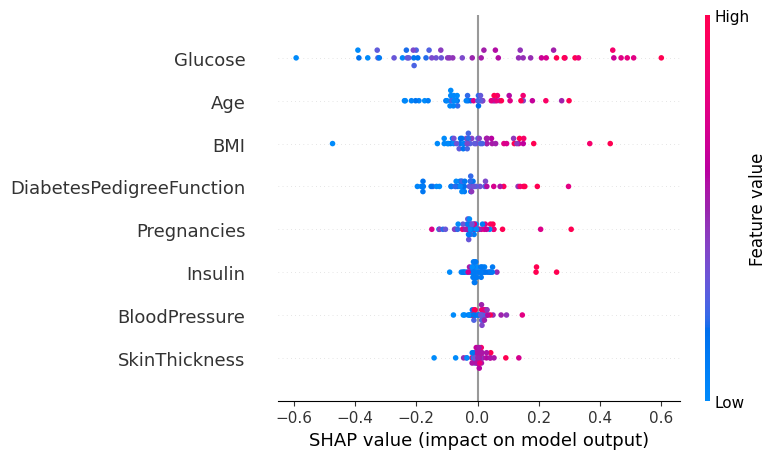

In [30]:
## SHAP
import shap

# KernelExplainer funciona com qualquer modelo
explainer = shap.KernelExplainer(svm_balanced.predict, 
                                  shap.sample(input_train, 50))

shap_values = explainer.shap_values(input_test.iloc[:50])

# gráfico de importância global das features
shap.summary_plot(shap_values, input_test.iloc[:50], 
                  feature_names=list(input_test.columns),
                  show=False)
plt.savefig('../reports/figures/shap_summary.png', bbox_inches='tight')
plt.show()